C:\Users\lenovo 2020\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


K-Means Evaluation Metrics
Homogeneity: 1.000, Completeness: 1.000, V-Measure: 1.000

Hierarchical Clustering Evaluation Metrics
Homogeneity: 1.000, Completeness: 1.000, V-Measure: 1.000


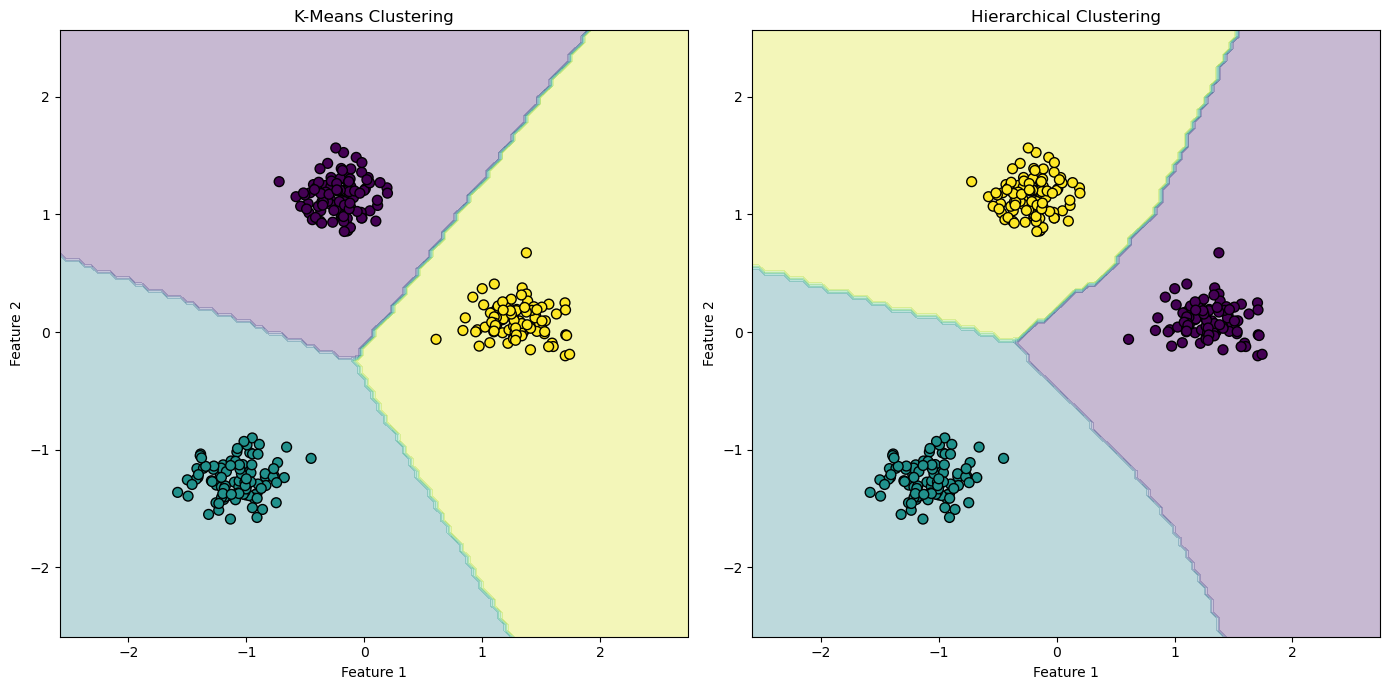


Confusion Matrix for K-Means:
[[100   0   0]
 [  0   0 100]
 [  0 100   0]]

Classification Report for K-Means:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       0.00      0.00      0.00       100
           2       0.00      0.00      0.00       100

    accuracy                           0.33       300
   macro avg       0.33      0.33      0.33       300
weighted avg       0.33      0.33      0.33       300


Confusion Matrix for Hierarchical Clustering:
[[  0   0 100]
 [100   0   0]
 [  0 100   0]]

Classification Report for Hierarchical Clustering:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     100.0
           1       0.00      0.00      0.00     100.0
           2       0.00      0.00      0.00     100.0

    accuracy                           0.00     300.0
   macro avg       0.00      0.00      0.00     300.0
weighted avg       0.00      0.00  

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, homogeneity_completeness_v_measure

# Generate synthetic data
X, y_true = make_blobs(n_samples=300, centers=3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
y_hierarchical = hierarchical.fit_predict(X)

# Define grid to plot decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predict for KMeans on the grid
kmeans_z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
kmeans_z = kmeans_z.reshape(xx.shape)

# Predict for Hierarchical Clustering on the grid
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y_hierarchical)
hierarchical_z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
hierarchical_z = hierarchical_z.reshape(xx.shape)

# Evaluation: Homogeneity, Completeness, and V-Measure
h_kmeans, c_kmeans, v_kmeans = homogeneity_completeness_v_measure(y_true, y_kmeans)
h_hierarchical, c_hierarchical, v_hierarchical = homogeneity_completeness_v_measure(y_true, y_hierarchical)

print("K-Means Evaluation Metrics")
print(f"Homogeneity: {h_kmeans:.3f}, Completeness: {c_kmeans:.3f}, V-Measure: {v_kmeans:.3f}")
print("\nHierarchical Clustering Evaluation Metrics")
print(f"Homogeneity: {h_hierarchical:.3f}, Completeness: {c_hierarchical:.3f}, V-Measure: {v_hierarchical:.3f}")

# Plotting the results for KMeans and Hierarchical Clustering
plt.figure(figsize=(14, 7))

# KMeans Plot
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, kmeans_z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', edgecolors='k', s=50)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Hierarchical Plot
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, hierarchical_z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y_hierarchical, cmap='viridis', edgecolors='k', s=50)
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

# Confusion Matrix and Classification Report for KMeans and Hierarchical Clustering
print("\nConfusion Matrix for K-Means:")
print(confusion_matrix(y_true, y_kmeans))
print("\nClassification Report for K-Means:")
print(classification_report(y_true, y_kmeans))

print("\nConfusion Matrix for Hierarchical Clustering:")
print(confusion_matrix(y_true, y_hierarchical))
print("\nClassification Report for Hierarchical Clustering:")
print(classification_report(y_true, y_hierarchical))
